In [1]:
# Colab compatibility: install packages not preinstalled there (no-op locally / on Colab reruns)
import importlib.util, subprocess, sys
for pkg, mod in [('faiss-cpu', 'faiss'), ('lightgbm', 'lightgbm')]:
    if importlib.util.find_spec(mod) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# 06 - MMR diversity re-ranking (bonus extension)

The ranker in notebook 05 only optimizes relevance. Its top-10 can come back with several near-identical books (same author, same series, same sub-genre) because they all score high on the same features. Maximal Marginal Relevance re-orders the ranked top-100 to trade a bit of that relevance for variety.

It needs no retraining. It reuses the two-tower item embeddings for item-item similarity and the LightGBM scores from notebook 05 for relevance. At each step MMR picks the candidate that maximizes

$$\text{score}(i) = \lambda \cdot \text{rel}(i) \; - \; (1-\lambda)\cdot \max_{j\in S}\text{sim}(i, j)$$

where $S$ is what's already been picked, `rel` is the ranker score (normalized per user), and `sim` is cosine similarity between item embeddings. At $\lambda = 1$ you get pure relevance, which is exactly notebook 05's order; at $\lambda = 0$ you get pure diversity. I tune $\lambda$ on validation and report on test, the same discipline used everywhere else.

## 0. Setup: load data, two-tower, and the notebook-05 ranker

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'   # macOS: torch/faiss/lightgbm each bundle OpenMP

import json, time
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import faiss, lightgbm as lgb
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)
device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available() else 'cpu')
SMOKE = False   # small user samples for a fast pipeline check; never report SMOKE numbers

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/recsys_kindle/data'
except ImportError:
    DATA_DIR = './data'
ART_TT = os.path.join(DATA_DIR, 'artifacts_two_tower')
ART_R  = os.path.join(DATA_DIR, 'artifacts_ranker')

train = pd.read_parquet(f'{DATA_DIR}/train.parquet')
val   = pd.read_parquet(f'{DATA_DIR}/val.parquet')
test  = pd.read_parquet(f'{DATA_DIR}/test.parquet')
mappings = json.load(open(f'{DATA_DIR}/id_mappings.json'))
N_ITEMS = len(mappings['item2idx'])

cfg = json.load(open(f'{ART_TT}/config.json'))
DIM, HIDDEN, MAX_HIST, PAD, GAMMA = cfg['dim'], cfg['hidden'], cfg['max_hist'], cfg['pad'], cfg.get('gamma', 1.0)

class TwoTower(nn.Module):
    """Must match notebook 04 exactly (state dict keys)."""
    def __init__(self, n_items, dim, hidden, gamma=1.0):
        super().__init__()
        self.emb = nn.Embedding(n_items + 1, dim, padding_idx=n_items)
        self.user_mlp = nn.Sequential(nn.Linear(dim, hidden), nn.ReLU(), nn.Linear(hidden, dim))
        self.item_mlp = nn.Sequential(nn.Linear(dim, hidden), nn.ReLU(), nn.Linear(hidden, dim))
        self.gamma = gamma
    def user_tower(self, hist, mask):
        pos = mask.cumsum(1); n = mask.sum(1, keepdim=True); dist = (n - pos).clamp(min=0)
        w = (self.gamma ** dist) * mask; w = w / w.sum(1, keepdim=True).clamp(min=1e-8)
        pooled = (self.emb(hist) * w.unsqueeze(-1)).sum(1)
        return F.normalize(self.user_mlp(pooled), dim=-1)

tower = TwoTower(N_ITEMS, DIM, HIDDEN, GAMMA).to(device)
tower.load_state_dict(torch.load(f'{ART_TT}/two_tower.pt', map_location=device)); tower.eval()

# item embeddings, L2-normalized -> dot product is cosine similarity (what MMR needs)
item_emb = np.load(f'{ART_TT}/item_embeddings.npy').astype('float32')
item_emb = item_emb / (np.linalg.norm(item_emb, axis=1, keepdims=True) + 1e-9)
index = faiss.read_index(f'{ART_TT}/faiss.index'); faiss.omp_set_num_threads(1)

# notebook-05 ranker + its exported feature tables
booster = lgb.Booster(model_file=f'{ART_R}/lgbm_ranker.txt')
FEATURES = json.load(open(f'{ART_R}/feature_config.json'))['features']
user_feat = pd.read_parquet(f'{ART_R}/user_features.parquet').set_index('user_idx')
item_feat = pd.read_parquet(f'{ART_R}/item_features.parquet').set_index('item_idx').reindex(range(N_ITEMS))
im = pd.read_parquet(f'{DATA_DIR}/items.parquet'); item_cat = im.set_index('item_idx')['category'].to_dict()
print(f'loaded {index.ntotal:,} items, {len(FEATURES)} ranker features, gamma={GAMMA}')

loaded 120,573 items, 12 ranker features, gamma=0.85


## 1. Rebuild the ranked candidates (retrieval + notebook-05 ranker)

For each user I take their train history, retrieve the two-tower top-100 (dropping train-seen items), and score every candidate with the notebook-05 LightGBM ranker. That gives the relevance signal MMR re-orders. `relevance_order` reproduces notebook 05's pure LightGBM order, which is the $\lambda=1$ baseline.

In [3]:
pos_sorted = train[train.is_positive].sort_values(['user_idx', 'timestamp'])
user_seqs = {int(u): g.item_idx.to_numpy(np.int64) for u, g in pos_sorted.groupby('user_idx')}
seen_train = train.groupby('user_idx')['item_idx'].agg(set).to_dict()
def build_truth(p):
    p = p[p.is_positive & p.user_idx.notna() & p.item_idx.notna()]
    return p.groupby('user_idx')['item_idx'].agg(set).to_dict()
truth_val, truth_test = build_truth(val), build_truth(test)
K_CAND = 100

@torch.no_grad()
def embed_users(users):
    hist = np.full((len(users), MAX_HIST), PAD, dtype=np.int64)
    for r, u in enumerate(users):
        seq = user_seqs.get(u, np.array([], dtype=np.int64))[-MAX_HIST:]
        hist[r, :len(seq)] = seq
    h = torch.as_tensor(hist, device=device)
    return tower.user_tower(h, (h != PAD).float()).cpu().numpy().astype('float32')

def retrieve_batch(users, k=K_CAND, batch=8192):
    out = {}
    for s in range(0, len(users), batch):
        chunk = users[s:s+batch]
        buf = max((len(seen_train.get(u, ())) for u in chunk), default=0) + 10
        D, I = index.search(embed_users(chunk), k + buf)
        for u, drow, irow in zip(chunk, D, I):
            seen = seen_train.get(u, set())
            keep = [(i, d) for i, d in zip(irow, drow) if i not in seen][:k]
            out[u] = (np.array([x[0] for x in keep]), np.array([x[1] for x in keep], dtype='float32'))
    return out

def ranker_preds(cand_dict):
    """-> {user: (items, ranker_scores)} for each retrieved candidate."""
    rows, meta = [], []
    for u, (items, scores) in cand_dict.items():
        uf = user_feat.loc[u] if u in user_feat.index else pd.Series(0.0, index=user_feat.columns)
        last5 = user_seqs.get(u, np.array([], dtype=np.int64))[-5:]
        max_sim = (item_emb[items] @ item_emb[last5].T).max(1) if len(last5) else np.zeros(len(items))
        ucats = {item_cat.get(int(i)) for i in user_seqs.get(u, [])[-20:]} - {None}
        itf = item_feat.loc[items]
        for r, (i, sc) in enumerate(zip(items, scores)):
            it = itf.loc[i] if i in itf.index else item_feat.iloc[int(i)]
            rows.append((uf.u_n_interactions, uf.u_avg_rating, uf.u_days_since_last, uf.u_n_recent_30d,
                         it.i_popularity, it.i_avg_rating, it.i_days_since_first, it.i_n_recent_30d,
                         sc, r, max_sim[r], float(item_cat.get(int(i)) in ucats)))
        meta.append((u, items, len(items)))
    X = pd.DataFrame(rows, columns=FEATURES).astype('float32')
    p = booster.predict(X, num_iteration=booster.best_iteration)
    out, b = {}, 0
    for u, items, n in meta:
        out[u] = (items, p[b:b+n]); b += n
    return out

def relevance_order(preds):
    return {u: [int(items[o]) for o in np.argsort(-p)] for u, (items, p) in preds.items()}

## 2. MMR re-ranking

Greedy selection over the 100 candidates. Relevance is min-max normalized per user so it sits on the same [0, 1] scale as cosine similarity, which is what lets $\lambda$ actually control the balance. I MMR-select the first 20 slots (enough for NDCG@10 and Recall@20) and append the rest in relevance order.

In [4]:
def mmr_order(items, rel, lam, k_sel=20):
    rel = (rel - rel.min()) / (rel.max() - rel.min() + 1e-9)   # per-user [0,1]
    E = item_emb[items]; S = E @ E.T                            # pairwise cosine (unit vectors)
    cand = list(range(len(items))); sel = []
    while cand and len(sel) < k_sel:
        if not sel:
            best = max(cand, key=lambda c: rel[c])
        else:
            best = max(cand, key=lambda c: lam * rel[c] - (1 - lam) * S[c, sel].max())
        sel.append(best); cand.remove(best)
    order = sel + sorted(cand, key=lambda c: -rel[c])
    return [int(items[o]) for o in order]

def rerank_all(preds, lam):
    return {u: mmr_order(items, p, lam) for u, (items, p) in preds.items()}

## 3. Metrics, plus a diversity measure

Same NDCG@10 / Recall@20 / Coverage@10 as the rest of the project, plus intra-list distance (ILD): the mean pairwise `1 - cosine` over the top-10. Higher ILD means a more varied list. That's the number MMR is supposed to move.

In [5]:
def ndcg_at_k(recs, truth, k=10):
    out = []
    for u, rel in truth.items():
        top = recs.get(u, [])[:k]
        dcg = sum(1 / np.log2(i + 2) for i, it in enumerate(top) if it in rel)
        idcg = sum(1 / np.log2(i + 2) for i in range(min(len(rel), k)))
        out.append(dcg / idcg if idcg > 0 else 0.0)
    return float(np.mean(out))

def recall_at_k(recs, truth, k=20):
    s = [len(set(recs.get(u, [])[:k]) & rel) / len(rel) for u, rel in truth.items() if rel]
    return float(np.mean(s)) if s else 0.0

def coverage_at_k(recs, k=10):
    seen = set()
    for r in recs.values(): seen.update(r[:k])
    return len(seen) / N_ITEMS

def intra_list_distance(recs, k=10):
    ds = []
    for r in recs.values():
        idx = r[:k]
        if len(idx) < 2: continue
        E = item_emb[idx]; S = E @ E.T; n = len(idx)
        ds.append((1 - S)[np.triu_indices(n, 1)].mean())
    return float(np.mean(ds))

## 4. Tune $\lambda$ on validation

Sweep $\lambda$ from 1.0 (pure relevance) to 0.0 (pure diversity) and plot the relevance-diversity
frontier: NDCG@10 against intra-list distance.

scored 6,000 validation users in 19s


,NDCG@10,Recall@20,IntraListDist@10,Coverage@10
lambda,,,,
1.0,0.0824,0.1304,0.3100,0.1186
0.9,0.0823,0.1303,0.3183,0.1191
0.8,0.0826,0.1304,0.3297,0.1198
0.7,0.0823,0.1308,0.3454,0.1201
0.6,0.0814,0.1303,0.3678,0.1203
0.5,0.0791,0.1289,0.3994,0.1217
0.3,0.0654,0.1098,0.4877,0.1355
0.0,0.0488,0.0588,0.5608,0.1789


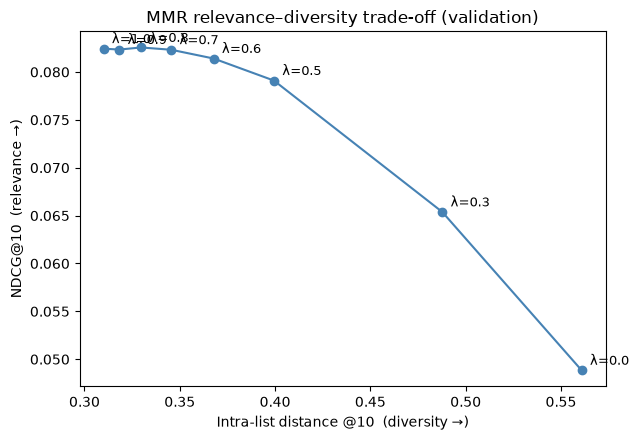

In [6]:
val_users = [u for u in truth_val if u in user_seqs]
val_users = list(rng.choice(val_users, size=min(2000 if SMOKE else 6000, len(val_users)), replace=False))
t0 = time.time(); vpred = ranker_preds(retrieve_batch(val_users))
truth_v = {u: truth_val[u] for u in val_users}
print(f'scored {len(vpred):,} validation users in {time.time()-t0:.0f}s')

lambdas = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.3, 0.0]
rows = []
for lam in lambdas:
    recs = relevance_order(vpred) if lam == 1.0 else rerank_all(vpred, lam)
    rows.append({'lambda': lam,
                 'NDCG@10': ndcg_at_k(recs, truth_v, 10),
                 'Recall@20': recall_at_k(recs, truth_v, 20),
                 'IntraListDist@10': intra_list_distance(recs, 10),
                 'Coverage@10': coverage_at_k(recs, 10)})
sweep = pd.DataFrame(rows).set_index('lambda')
display(sweep.round(4))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(sweep['IntraListDist@10'], sweep['NDCG@10'], '-o', color='steelblue')
for lam, r in sweep.iterrows():
    ax.annotate(f'λ={lam}', (r['IntraListDist@10'], r['NDCG@10']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)
ax.set_xlabel('Intra-list distance @10  (diversity →)')
ax.set_ylabel('NDCG@10  (relevance →)')
ax.set_title('MMR relevance-diversity trade-off (validation)')
plt.tight_layout(); plt.show()

**Interpretation.** On validation the trade-off is gentle up top: lambda 0.8 even edges out pure relevance on NDCG@10 (0.0826 vs 0.0824) while raising diversity. Below about 0.6 relevance drops fast. Useful range is roughly 0.6 to 0.9.

## 5. Report on test + pick the serving default

Same before/after on held-out test users, across a few lambda values so the choice is grounded on the
data the model never saw.

In [7]:
test_users = [u for u in truth_test if u in user_seqs]
test_users = list(rng.choice(test_users, size=min(5000 if SMOKE else 15000, len(test_users)), replace=False))
t0 = time.time(); tpred = ranker_preds(retrieve_batch(test_users))
truth_t = {u: truth_test[u] for u in test_users}
print(f'scored {len(tpred):,} test users in {time.time()-t0:.0f}s')

rows = [{'config': 'ranker only (λ=1.0)', **{}}]
def metrics_row(name, recs):
    return {'config': name,
            'NDCG@10': ndcg_at_k(recs, truth_t, 10),
            'Recall@20': recall_at_k(recs, truth_t, 20),
            'IntraListDist@10': intra_list_distance(recs, 10),
            'Coverage@10': coverage_at_k(recs, 10)}
res = [metrics_row('ranker only (λ=1.0)', relevance_order(tpred))]
for lam in [0.9, 0.8, 0.7, 0.6]:
    res.append(metrics_row(f'+MMR (λ={lam})', rerank_all(tpred, lam)))
test_tbl = pd.DataFrame(res).set_index('config')
display(test_tbl.round(4))

LAMBDA_SERVE = 0.7   # serving default (see interpretation below)
test_tbl.round(4).to_json(os.path.join(DATA_DIR, 'mmr_results.json'), orient='index', indent=2)
print(f'serving default lambda = {LAMBDA_SERVE}; saved mmr_results.json')

scored 15,000 test users in 46s


,NDCG@10,Recall@20,IntraListDist@10,Coverage@10
config,,,,
ranker only (λ=1.0),0.0304,0.0714,0.3150,0.1961
+MMR (λ=0.9),0.0302,0.0718,0.3235,0.1966
+MMR (λ=0.8),0.0298,0.0712,0.3350,0.1975
+MMR (λ=0.7),0.0291,0.0704,0.3511,0.1982
+MMR (λ=0.6),0.0281,0.0695,0.3735,0.1995


serving default lambda = 0.7; saved mmr_results.json


**Interpretation.** On test the near-free diversity fades (val->test drift again): every step down in lambda costs some NDCG. I set the serving default to 0.7: about -4% NDCG for +11% intra-list diversity, with lambda=1.0 still available as pure relevance.

## 6. Serving

The API exposes this as a per-request toggle. `app/api/model_service.py` takes an optional `mmr_lambda`: when it's set, the endpoint runs this same greedy MMR over the ranked top-100 using the stored item embeddings (no extra model, no retraining); when it's left off, the endpoint behaves exactly as before. The app passes `lambda = 0.7` to turn it on, following the analysis above.